# Before you Start

You will need to install several things before you can start

### 1. Installing Python dependencies with pip:
    Go download R from https://www.r-project.org

    Open a new R console and run:
        ~ install.packages('IRkernel')
        ~ install.packages('ggplot2')
    
    Then, in your terminal, run:
        ~ R
        ~ IRkernel::installspec()
    For more information on installing IRkernel, visit: https://irkernel.github.io/installation

### 2. Download a JDK
    Download and follow prompts
    https://www.oracle.com/technetwork/java/javase/downloads/jdk12-downloads-5295953.html

### 3. Set up R in Jupyter Notebooks
    Follow the instructions here through step 3
    https://docs.anaconda.com/anaconda/navigator/tutorials/r-lang/

# Outline

1) [What is Factor Analysis](#background)

2) [Prep (including PCA)](#prep)

3) [Factor Analysis](#analysis)

3) [Using the Factors](#use)

<a id='background'></a>
# What is Factor Analysis

Factor analysis is a dimension reduction method, combining multiple variables into a single component.  For example, say we wanted to measure a student's confidence over the course of this survey.  It is possible to include their reported confidence for each question and use them as individual predictors, but really we care more about their overall confidence.  Thus, we use the average confidence levels over the entire study.  This will mitigate issues of multicolinearity and make the conclusions more intuative and easy to understand.  Average confidence is a straightforward dimension reduction example.  Factor analysis is a slightly more involved way to do this in a more general setting.  

## Background

We will be using data from Professor Kate Follete's QuaRCS quantitative skills assesment.  The goal of this survey is to measure the quantitative skills in STEM for non-majors courses, with the hope that an accurate and reliable metric will help professors improve their courses.  For most of this walkthrough we will assume you are familiar with the project or care only about the techniques rather than the content.  

### What is Factor Analysis

If you are unfamiliar with factor analysis, there are a lot of great background readings.  Here are a couple:

**General Background**

https://en.wikipedia.org/wiki/Factor_analysis

http://ocw.jhsph.edu/courses/StatisticsPsychosocialResearch/PDFs/Lecture8.pdf

**With this kind of survey data (mostly focused on exploratory)**

http://www.let.rug.nl/nerbonne/teach/rema-stats-meth-seminar/Factor-Analysis-Kootstra-04.PDF

http://pareonline.net/pdf/v10n7.pdf

http://www.statisticssolutions.com/factor-analysis-sem-exploratory-factor-analysis/

**Computing in R**

https://www.statmethods.net/advstats/factor.html

https://www.r-bloggers.com/factor-analysis-introduction-with-the-principal-component-method-and-r/


### Typical Outline

1) Do a PCA (with Scree Plot) to determine how many factors

    a) One factor before the "elbow" is often a good number

2) **Exploratory Factor Analysis** - What we're mostly doing here

3) Confirmatory Factor Analysis

<a id='prep'></a>
# Factor Analysis Prep

We begin by loading in the required libraries and reading in the data.  

In [1]:
install.packages('mosaic')
install.packages('foreign')
install.packages('tidyverse')
install.packages('magrittr')
install.packages('psych')
install.packages('GPArotation')


The downloaded binary packages are in
	/var/folders/br/pg7rbr9x4zg1fbqbnkclq5380000gq/T//Rtmp2DOPPR/downloaded_packages

The downloaded binary packages are in
	/var/folders/br/pg7rbr9x4zg1fbqbnkclq5380000gq/T//Rtmp2DOPPR/downloaded_packages


also installing the dependencies ‘sys’, ‘ps’, ‘highr’, ‘askpass’, ‘rematch’, ‘prettyunits’, ‘processx’, ‘knitr’, ‘tinytex’, ‘xfun’, ‘DBI’, ‘curl’, ‘openssl’, ‘cellranger’, ‘progress’, ‘callr’, ‘fs’, ‘rmarkdown’, ‘whisker’, ‘selectr’, ‘dbplyr’, ‘forcats’, ‘haven’, ‘httr’, ‘lubridate’, ‘modelr’, ‘readxl’, ‘reprex’, ‘rstudioapi’, ‘rvest’, ‘xml2’




The downloaded binary packages are in
	/var/folders/br/pg7rbr9x4zg1fbqbnkclq5380000gq/T//Rtmp2DOPPR/downloaded_packages

The downloaded binary packages are in
	/var/folders/br/pg7rbr9x4zg1fbqbnkclq5380000gq/T//Rtmp2DOPPR/downloaded_packages


also installing the dependency ‘mnormt’




The downloaded binary packages are in
	/var/folders/br/pg7rbr9x4zg1fbqbnkclq5380000gq/T//Rtmp2DOPPR/downloaded_packages

The downloaded binary packages are in
	/var/folders/br/pg7rbr9x4zg1fbqbnkclq5380000gq/T//Rtmp2DOPPR/downloaded_packages


In [19]:
suppressMessages(library(mosaic))
suppressMessages(library(foreign))
suppressMessages(library(tidyverse))
suppressMessages(library(magrittr))
suppressMessages(library(psych))
suppressMessages(library(GPArotation))

<font color="red">------------------------------------------***Place To Change: Read in the correct data***-----------------------------------------------------</font>

In [20]:
suppressWarnings(df <- read.csv("QuaRCS_Lt2_Pre_scored.csv"))

<font color="red">----------------------------------------------------------------------------------------------------------------------</font>

Then, we need to do some data cleaning steps.  Basically, I am selecting only those variables that I care about.  I am also converting the likard questions into numerical format, as factor analysis in R requires quantitative variables.  There is a way to read in SPSS data with all numerical values, but I originally made this to work on a .csv file that didn't have those features and I was too lazy to change it.

In [21]:
# Here I'm averaging the students confidence for all the questions

# First, define the variables of interest
vars <- c("PRE_FREQEN","PRE_DAILYM","PRE_DAILYG","PRE_ATT_DL_1", "PRE_ATT_DL_2", 
          "PRE_ATT_DL_3", "PRE_ATT_DL_4", "PRE_ATT_DL_5", "PRE_ATT_SC_1", "PRE_ATT_SC_2", 
          "PRE_ATT_SC_3", "PRE_ATT_SC_4", "PRE_ATT_SC_5", "PRE_LK1", "PRE_LK2", "PRE_LK5",
          "PRE_ANX.1_1", "PRE_ANX.1_2", "PRE_ANX.1_3", "PRE_ANX.1_4","PRE_WHYMAJ_1",
          "PRE_WHYMAJ_2","PRE_WHYMAJ_3","PRE_WHYMAJ_4","PRE_WHYMAJ_5", 
          "PRE_CF_TOTAL")

#### Now select the data
d <- df[,c(vars)]


# Sometimes, SPSS recorded "No" as NA.  This changes it to 0
#d[, c("PRE_WHYMAJ_LIKE","PRE_WHYMAJ_LIKEJOB","PRE_WHYMAJ_MONEY","PRE_WHYMAJ_GOOD","PRE_WHYMAJ_NOMATH")][is.na(d[, c("PRE_WHYMAJ_LIKE","PRE_WHYMAJ_LIKEJOB","PRE_WHYMAJ_MONEY","PRE_WHYMAJ_GOOD","PRE_WHYMAJ_NOMATH")])] <- 0




Once the data is cleaned and ready to use, we can start the factor analysis!

<font color="red">------------------------------------------***Place To Change: Select the correct vatiables***-----------------------------------------------------</font>

In [22]:
# First, we need students to answer all the questions.  We cannot use incomplete data
d0 <- d[complete.cases(d),]

# Uncomment to see the variable names of data so that you can select the ones you want
names(d0)

# This is another round of variable selection
# For instance, for now we believe that "Why Students Choose Their Major" does not matter
d1 <- d0[,c(1:20, 26)]
d1 <- d1[,c(-11,-5,-4,-7,-8)]

[1] "PRE_FREQEN"   "PRE_DAILYM"   "PRE_DAILYG"   "PRE_ATT_DL_1" "PRE_ATT_DL_2"
 [6] "PRE_ATT_DL_3" "PRE_ATT_DL_4" "PRE_ATT_DL_5" "PRE_ATT_SC_1" "PRE_ATT_SC_2"
[11] "PRE_ATT_SC_3" "PRE_ATT_SC_4" "PRE_ATT_SC_5" "PRE_LK1"      "PRE_LK2"     
[16] "PRE_LK5"      "PRE_ANX.1_1"  "PRE_ANX.1_2"  "PRE_ANX.1_3"  "PRE_ANX.1_4" 
[21] "PRE_WHYMAJ_1" "PRE_WHYMAJ_2" "PRE_WHYMAJ_3" "PRE_WHYMAJ_4" "PRE_WHYMAJ_5"
[26] "PRE_CF_TOTAL"

In [23]:
colnames(d1)

[1] "PRE_FREQEN"   "PRE_DAILYM"   "PRE_DAILYG"   "PRE_ATT_DL_3" "PRE_ATT_SC_1"
 [6] "PRE_ATT_SC_2" "PRE_ATT_SC_4" "PRE_ATT_SC_5" "PRE_LK1"      "PRE_LK2"     
[11] "PRE_LK5"      "PRE_ANX.1_1"  "PRE_ANX.1_2"  "PRE_ANX.1_3"  "PRE_ANX.1_4" 
[16] "PRE_CF_TOTAL"

<font color="red">----------------------------------------------------------------------------------------------------------------------</font>

## How Many Factors?

One we've selected the variables we want to use, we need to decide how many factors to create.  We'll start with a [Scree plot](https://www.theanalysisfactor.com/factor-analysis-how-many-factors/), which shows the amount of additional varaince each factor will explain.  Typically, we want to choose factors that explain more varaince, so when the plot levels off (often called the "elbow") we stop.  We can also use linear algebra and calculate the eigen values of the correlation matrix, with important factors having an eigen value greater than 1.  The two methods sometimes produce slightly different restults, so go with whatever makes the most sense.  

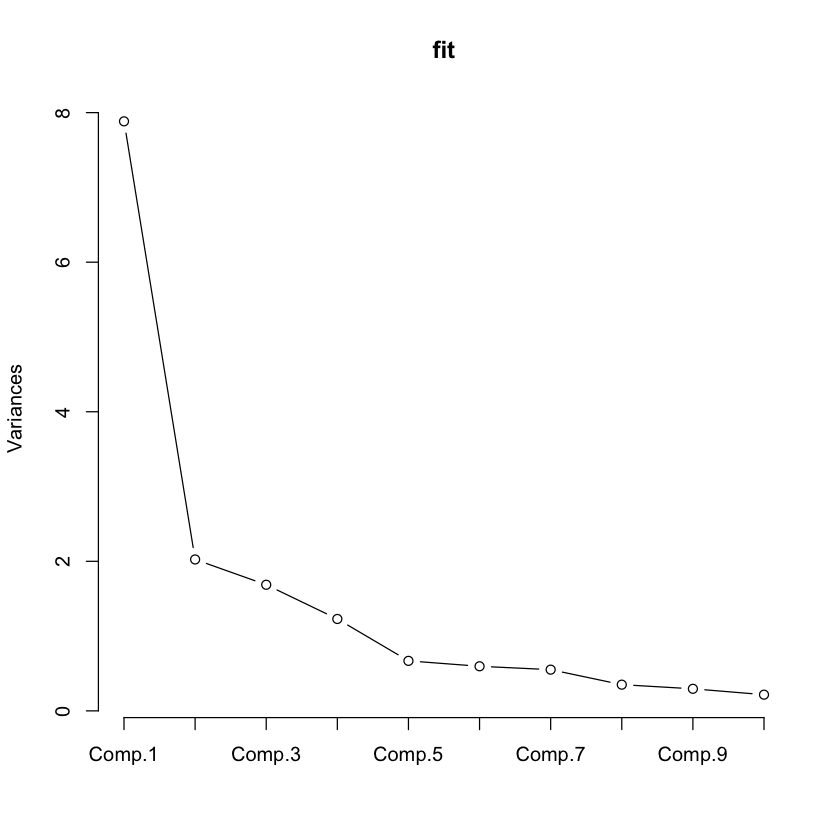

In [24]:
fit <- princomp(d1, cor=TRUE)
plot(fit,type="lines")

The scree plot suggests that we may need as many as 5 or 6 factors to explain the variance in the data.  With effort counting as one on it's own, that means we need 4 or 5 combined factors.

In [25]:
summary(fit)

Importance of components:
                          Comp.1    Comp.2    Comp.3    Comp.4     Comp.5
Standard deviation     2.8078100 1.4229524 1.2986371 1.1085868 0.81776187
Proportion of Variance 0.4927373 0.1265496 0.1054036 0.0768103 0.04179591
Cumulative Proportion  0.4927373 0.6192869 0.7246905 0.8015008 0.84329675
                           Comp.6     Comp.7     Comp.8     Comp.9   Comp.10
Standard deviation     0.77207860 0.74248794 0.59206168 0.54318820 0.4654203
Proportion of Variance 0.03725659 0.03445552 0.02190856 0.01844084 0.0135385
Cumulative Proportion  0.88055334 0.91500886 0.93691742 0.95535826 0.9688968
                          Comp.11     Comp.12     Comp.13     Comp.14
Standard deviation     0.42944171 0.378848952 0.311050110 0.220195228
Proportion of Variance 0.01152626 0.008970408 0.006047011 0.003030371
Cumulative Proportion  0.98042303 0.989393435 0.995440446 0.998470817
                           Comp.15      Comp.16
Standard deviation     0.152742132 3.37160

Again, there is an art as to when we are comfortable stopping.  This table shows the additional variance in the data explained by each new factor.  There is no hard and fast rule as to where to stop.  We chose 5 (again, effort counts for one on its own, so we generated 4 factors).  Adding too many factors minimizes the effectiveness of factor analysis and potentially leave you vulnerable to [overfitting](http://scott.fortmann-roe.com/docs/BiasVariance.html).

<a id='analysis'></a>
# Factor Analysis

In [28]:
# This is the actual Factor Analysis

## We start by generating a correlation matrix
f <- cor(d1, use="complete.obs")

## Oblimin Factor Analysis to allow correlation between predictors
preK <-  fa(r=f, nfactors = 4,fm="ml", rotate ="oblimin",  oblique.scores = TRUE, max.iter = 25)
## This is a kaiser rotation.  It's standard in SPSS, but isn't used that much elsewhere
## The reason we use it here is to replicate earlier findings from this lab, which used SPSS for analysis
load4 <- kaiser(preK)


# Here I'm extracting the loadings into a nice little table so we can analyze
loadings4 <- load4$loadings[c(1:ncol(d1)),]
loadings4 <- apply(loadings4, 2, function(x) ifelse(abs(x)>0.32,x,NA))

# Look at factor loadings
loadings4

,ML1,ML3,ML2,ML4
PRE_FREQEN,-0.4770035,-0.4197782,NA,NA
PRE_DAILYM,NA,NA,NA,-0.7836489
PRE_DAILYG,-0.4774800,NA,NA,NA
PRE_ATT_DL_3,NA,0.4040415,NA,0.4343120
PRE_ATT_SC_1,0.7764838,NA,NA,NA
PRE_ATT_SC_2,0.7982764,NA,NA,NA
PRE_ATT_SC_4,0.5762998,NA,-0.3965922,NA
PRE_ATT_SC_5,0.9890108,-0.3362635,NA,NA
PRE_LK1,NA,-0.3587373,NA,NA
PRE_LK2,NA,NA,0.9102156,NA


Here we can see which factors load togeather and how strong they load.  I only included loadings that are greater than 0.32 (which is a common cutoff for significance).  

This particular matrix is known as a [pattern matrix](https://stats.stackexchange.com/questions/166799/which-matrix-should-be-interpreted-in-factor-analysis-pattern-matrix-or-structu).  We are analyzing this rather than the structure matrix because we assume some correlation between our factors.  Read the link to understand more about the difference.

# Creating the Factors

Now that we've fit the factors, we can use them to generate scores for each student.  The orignal analysis had done an [Anderson-Rubin scoring mechanism](https://www.ibm.com/support/knowledgecenter/en/SSLVMB_24.0.0/spss/base/idh_fact_sco.html), which is notated in R as "tenBerge".

In [34]:
factor <- factor.scores(d1, load4,  method = "tenBerge")
factors <- factor$scores

score <- df$PRE_TOTAL
effort <- df$PRE_EFFORT

test <- cbind(score = score, factors, effort)
test <- as.data.frame(test)

Warning message in cbind(score = score, factors, effort):
“number of rows of result is not a multiple of vector length (arg 1)”

Now that we have the factors, we should look at a correlation table to ensure that we're not going to run into multicollinearity issues with factors that are too highly correlated with each other.  

In [35]:
cor(test)

,score,ML1,ML3,ML2,ML4,effort
score,1.00000000,-0.03127734,-0.33105316,0.2489890457,-0.3047819016,0.72225103
ML1,-0.03127734,1.00000000,0.19623311,-0.1130126733,0.1099098348,-0.04074595
ML3,-0.33105316,0.19623311,1.00000000,-0.0642673763,0.1429960353,-0.09287699
ML2,0.24898905,-0.11301267,-0.06426738,1.0000000000,0.0004245609,0.31786686
ML4,-0.30478190,0.10990983,0.14299604,0.0004245609,1.0000000000,-0.32743377
effort,0.72225103,-0.04074595,-0.09287699,0.3178668641,-0.3274337742,1.00000000


There is not a huge correlation between the factors.  Effort is fairly highly correlated with everything except for our second factor, which will turn out to be non-informative anyways.  This isn't ideal, but was expected.

Now we can see how well these factors predict assesment performance.  If we had a large sample, we would ideally train the factors on a distinct subset from the testing data.  This was not done here as our primary goal was to reproduce previous findings.

<a id='use'></a>
# Using the Factors

In [36]:
# Factor 2 was determined to be not significent statistically or in practice and was dropped from the model
m4 <- lm(score~., data = test)

msummary(m4)

            Estimate Std. Error t value Pr(>|t|)   
(Intercept) -0.46916    3.26222  -0.144  0.88803   
ML1          0.23446    0.76728   0.306  0.76517   
ML3         -1.10091    0.76701  -1.435  0.17674   
ML2          0.09558    0.79718   0.120  0.90655   
ML4         -0.20868    0.80376  -0.260  0.79955   
effort       2.43435    0.74358   3.274  0.00666 **

Residual standard error: 3.072 on 12 degrees of freedom
Multiple R-squared:  0.597,	Adjusted R-squared:  0.4291 
F-statistic: 3.555 on 5 and 12 DF,  p-value: 0.03334

From here you can add other variables into the model, such as sex, race and major.  These factors now simply serve as regular predictors.  

## How did the factors do?

We now want to see how each additional factor did.  We'll run a linear model adding each factor one at a time and see how much of the variance in the data it explains (R^2).  

In [37]:
names(test)

[1] "score"  "ML1"    "ML3"    "ML2"    "ML4"    "effort"

In [39]:
m1s <- lm(score~ML4+ML1+ML3+effort, data = test)
m2s <- lm(score~effort + ML1, data = test)
m4s <- lm(score~effort + ML1 + ML4, data = test)
m5s <- lm(score~effort + ML1 + ML4 + ML3, data = test)
m6s <- lm(score~effort + ML1 + ML4 + ML3 + ML2, data = test)
msummary(m1s)

            Estimate Std. Error t value Pr(>|t|)   
(Intercept)  -0.5976     2.9623  -0.202  0.84325   
ML4          -0.1960     0.7660  -0.256  0.80202   
ML1           0.2242     0.7330   0.306  0.76456   
ML3          -1.1037     0.7370  -1.498  0.15814   
effort        2.4644     0.6731   3.661  0.00287 **

Residual standard error: 2.953 on 13 degrees of freedom
Multiple R-squared:  0.5965,	Adjusted R-squared:  0.4724 
F-statistic: 4.805 on 4 and 13 DF,  p-value: 0.01337

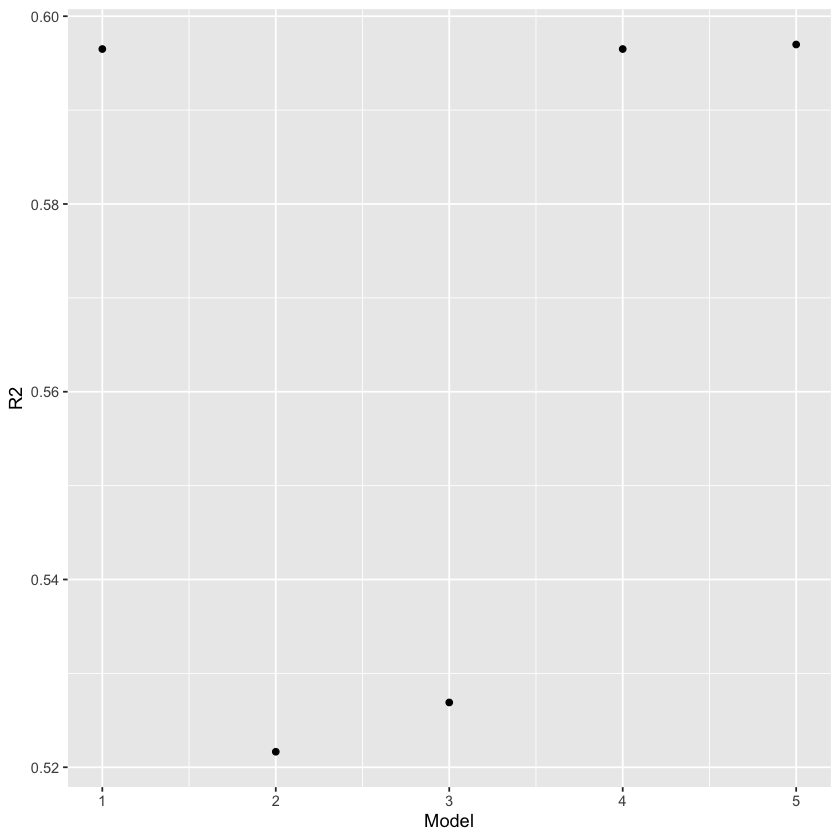

In [40]:
df <- data.frame(Model = seq(1,5,1), R2 = c(summary(m1s)$r.squared,summary(m2s)$r.squared,summary(m4s)$r.squared,summary(m5s)$r.squared,summary(m6s)$r.squared))
ggplot(df)+
geom_point(aes(Model, R2))+
labs(list(title = "Effectiveness of Each Additional Factor in Linear Regression Model"))

It turns out that the last factor didn't help all that much.  We won't (and didn't) use it in our model.  